In [1]:
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    train_test_split, cross_val_score, GroupKFold,
)

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")

data inladen + enkele waarden bekijken

In [2]:
df_env = pd.read_csv("ClimateBiodiversity/Data/Diversity_data_with_env.csv")
df_biooracle = pd.read_csv("ClimateBiodiversity/Data/Diversity_data_with_biooracle_2010.csv")

print(f"env data:             {df_env.shape}")
df_env.columns
df_env.head()

env data:             (2452, 33)


,grid_id,long,lat,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,long_dd,lat_dd,...,Shelf,Slope,Abyssal,TidalRange,Coral,Estuary,Seamount,MPA,matched_CenterLong,matched_CenterLat
0,1,-17174579,-7123536,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,0.0,730.228795,263.361205,-9999.0,0.0,0.0,0,NaN,-171.75,-71.25
1,2,-16788679,-7123536,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-167.75,-71.25
2,3,-16402779,-7123536,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-164.25,-71.25
3,4,-16016879,-7123536,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-160.25,-71.25
4,5,-15630979,-7123536,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,0.0,0.000000,993.590000,-9999.0,0.0,0.0,0,NaN,-156.25,-71.25


lijst van alle variabelen

In [3]:
df_biooracle.head()

,marine_species_richness,PD,co1_genetic_diversity_mean,long_deg,lat_deg,chl_max,chl_mean,chl_min,clt_max,clt_mean,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,44,11.830844,0.007171,-171.74579,-71.23536,1.987486,0.264222,0.015311,0.993542,0.681597,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,43,11.830844,0.007171,-167.88679,-71.23536,2.205368,0.278952,0.015232,0.961121,0.693978,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,44,12.650381,0.007499,-164.02779,-71.23536,1.891105,0.270836,0.015052,0.960210,0.698352,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,44,12.650381,0.007499,-160.16879,-71.23536,1.963815,0.293940,0.015424,0.962838,0.693123,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,45,12.650381,0.007499,-156.30979,-71.23536,1.956123,0.298378,0.015726,0.969080,0.688964,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [4]:
df_biooracle.columns

Index(['marine_species_richness', 'PD', 'co1_genetic_diversity_mean',
       'long_deg', 'lat_deg', 'chl_max', 'chl_mean', 'chl_min', 'clt_max',
       'clt_mean', 'clt_min', 'currentdirection_max', 'currentdirection_mean',
       'currentdirection_min', 'currentvelocity_ltmax', 'currentvelocity_max',
       'currentvelocity_mean', 'currentvelocity_min', 'dfe_max', 'dfe_mean',
       'dfe_min', 'kdpar_max', 'kdpar_mean', 'kdpar_min', 'mlotst_max',
       'mlotst_mean', 'mlotst_min', 'no3_max', 'no3_mean', 'no3_min', 'o2_max',
       'o2_mean', 'o2_min', 'par_mean', 'par_min', 'phyc_max', 'phyc_mean',
       'phyc_min', 'ph_max', 'ph_mean', 'ph_min', 'po4_max', 'po4_mean',
       'po4_min', 'salinity_ltmax', 'salinity_ltmin', 'salinity_max',
       'salinity_mean', 'salinity_min', 'salinity_range', 'siconc_max',
       'siconc_mean', 'siconc_min', 'sithick_max', 'sithick_mean',
       'sithick_min', 'si_max', 'si_mean', 'si_min', 'tas_max', 'tas_mean',
       'tas_min', 'terrain_charact

kijken welke variabelen encoding nodig hebben

In [5]:
print(df_env.ClimZoneCode) 

0       SP
1       SP
2       SP
3       SP
4       SP
        ..
2447    NP
2448    NP
2449    NP
2450    NP
2451    NP
Name: ClimZoneCode, Length: 2452, dtype: object


encoding uitvoeveren en toevoegen aan dataset --> deze gebruiken in model!

In [6]:
df_env.ClimZoneCode
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_env["ClimZoneCode_encoded"] = le.fit_transform(df_env["ClimZoneCode"])
df_env["ClimZoneCode_encoded"]

0       5
1       5
2       5
3       5
4       5
       ..
2447    1
2448    1
2449    1
2450    1
2451    1
Name: ClimZoneCode_encoded, Length: 2452, dtype: int32

target uitkiezen (genetische diversiteit) + variabelen in model
 --> eerst correlaties bekijken met GD, als heel lage correlatie dan niet opnemen in model

data exploratie eerst 

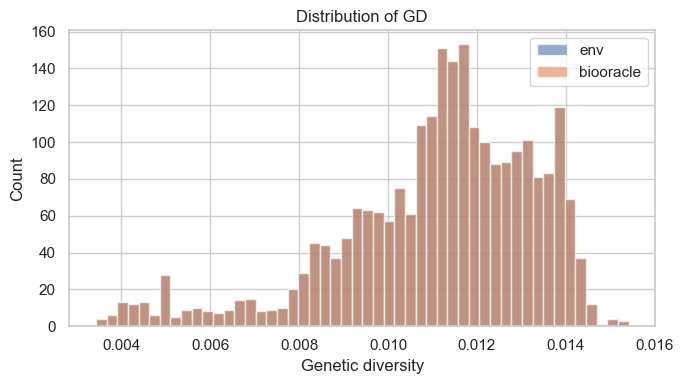

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(df_env["co1_genetic_diversity_mean"], bins=50, edgecolor="white", alpha=0.6, label= "env")
ax.hist(df_biooracle["co1_genetic_diversity_mean"], bins=50, edgecolor="white", alpha=0.6, label="biooracle")

ax.set_xlabel("Genetic diversity")
ax.set_ylabel("Count")
ax.set_title("Distribution of GD")
ax.legend()
plt.tight_layout()
plt.show()

2 datasets samenvoegen o.b.v. locatie 

In [14]:
df_merge = pd.merge(df_env, df_biooracle, on = ["long_deg", "lat_deg"], how = "inner")

In [15]:
print(f"merged data:             {df_merge.shape}")
df_merge.head()

merged data:             (2452, 107)


,grid_id,long,lat,marine_species_richness_x,PD_x,co1_genetic_diversity_mean_x,long_deg,lat_deg,long_dd,lat_dd,...,terrain_characteristics_bea_min,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_ltmax,T_ltmin,T_max,T_mean,T_min,T_range
0,1,-17174579.0,-7123536.0,44,11.830844,0.007171,-171.74579,-71.23536,-171.74579,-71.23536,...,-3883.0,66.347260,0.933108,6.854279,-0.711044,-1.904281,-0.127859,-1.602750,-1.977225,1.849366
1,2,-16788679.0,-7123536.0,43,11.830844,0.007171,-167.88679,-71.23536,-167.88679,-71.23536,...,-4084.0,21.055542,0.320794,-12.930603,-0.847708,-1.925544,-0.017505,-1.620118,-2.000000,1.988636
2,3,-16402779.0,-7123536.0,44,12.650381,0.007499,-164.02779,-71.23536,-164.02779,-71.23536,...,-4153.0,14.489563,0.228825,5.524109,-0.521772,-1.923338,0.125601,-1.582915,-2.000000,2.137620
3,4,-16016879.0,-7123536.0,44,12.650381,0.007499,-160.16879,-71.23536,-160.16879,-71.23536,...,-4303.0,4.413208,0.081748,1.760254,-0.558407,-1.909406,-0.032617,-1.579760,-1.976150,1.943533
4,5,-15630979.0,-7123536.0,45,12.650381,0.007499,-156.30979,-71.23536,-156.30979,-71.23536,...,-4341.0,10.302124,0.234018,-0.892456,-0.570859,-1.906482,-0.000029,-1.570748,-2.000000,2.001978


In [16]:
df_merge.columns

Index(['grid_id', 'long', 'lat', 'marine_species_richness_x', 'PD_x',
       'co1_genetic_diversity_mean_x', 'long_deg', 'lat_deg', 'long_dd',
       'lat_dd',
       ...
       'terrain_characteristics_bea_min', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_ltmax', 'T_ltmin', 'T_max', 'T_mean', 'T_min', 'T_range'],
      dtype='object', length=107)

onnodige kolommen verwijderen

In [44]:
cols_to_drop = df_merge.filter(regex=r'(?i)(min|max|range)').columns
df_merge_variables = df_merge.drop(columns=cols_to_drop)
df_merge_variables.drop(columns=["marine_species_richness_x","co1_genetic_diversity_mean_x", "PD_x", "grid_id", "long", "lat", "long_dd", "lat_dd", "ClimZoneCode", "matched_CenterLong", "matched_CenterLat", "marine_species_richness_y", "PD_y" ], inplace=True)

In [45]:
df_merge_variables.columns

Index(['long_deg', 'lat_deg', 'DepthMean', 'SSTAnMean', 'SBTAnMean',
       'SalinityMean', 'SalinityBMean', 'PrimProdMean', 'IceConAnn', 'OxyMean',
       'OxyBMean', 'LandDist', 'Shelf', 'Slope', 'Abyssal', 'Coral', 'Estuary',
       'Seamount', 'MPA', 'ClimZoneCode_encoded',
       'co1_genetic_diversity_mean_y', 'chl_mean', 'clt_mean',
       'currentdirection_mean', 'currentvelocity_mean', 'dfe_mean',
       'kdpar_mean', 'mlotst_mean', 'no3_mean', 'o2_mean', 'par_mean',
       'phyc_mean', 'ph_mean', 'po4_mean', 'salinity_mean', 'siconc_mean',
       'sithick_mean', 'si_mean', 'tas_mean', 'terrain_characteristics_aspect',
       'terrain_characteristics_bea_mean', 'terrain_characteristics_rug',
       'terrain_characteristics_slope', 'terrain_characteristics_topo',
       'T_mean'],
      dtype='object')

In [46]:
print(f"data model:             {df_merge_variables.shape}")
df_merge_variables.head()

data model:             (2452, 45)


,long_deg,lat_deg,DepthMean,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
0,-171.74579,-71.23536,3998,-1.693377,-0.049802,33.934307,34.705566,1.153,0.708033,308.798553,...,0.731921,0.682407,103.700478,-12.067131,10.920937,-3936.972168,66.347260,0.933108,6.854279,-1.602750
1,-167.88679,-71.23536,4079,-1.697129,-0.070504,33.976231,34.703896,1.141,0.702925,309.091431,...,0.727964,0.742742,104.054313,-11.786772,141.201179,-4093.388916,21.055542,0.320794,-12.930603,-1.620118
2,-164.02779,-71.23536,4185,-1.658674,-0.071121,33.934555,34.703419,1.120,0.694178,311.400299,...,0.693648,0.713952,102.867443,-11.387081,216.269828,-4160.611328,14.489563,0.228825,5.524109,-1.582915
3,-160.16879,-71.23536,4231,-1.629549,-0.072501,33.875896,34.703423,1.169,0.679715,313.670135,...,0.693803,0.720227,99.723148,-10.962065,224.836870,-4305.361328,4.413208,0.081748,1.760254,-1.579760
4,-156.30979,-71.23536,4322,-1.620574,-0.066624,33.789886,34.710335,1.094,0.683326,315.589600,...,0.687315,0.703112,97.156055,-10.534314,300.267603,-4353.527832,10.302124,0.234018,-0.892456,-1.570748


target en variabelen selecteren

In [47]:
target = "co1_genetic_diversity_mean_y" # Geselecteerde biodiversiteitsmaat om te voorspellen.
feature_cols = df_merge_variables.columns.drop(["long_deg", "lat_deg", "co1_genetic_diversity_mean_y"]).tolist()

df = df_merge_variables[[target] + feature_cols].copy()
print(f"Shape before cleaning: {df.shape}")
df.describe()

Shape before cleaning: (2452, 43)


,co1_genetic_diversity_mean_y,DepthMean,SSTAnMean,SBTAnMean,SalinityMean,SalinityBMean,PrimProdMean,IceConAnn,OxyMean,OxyBMean,...,siconc_mean,sithick_mean,si_mean,tas_mean,terrain_characteristics_aspect,terrain_characteristics_bea_mean,terrain_characteristics_rug,terrain_characteristics_slope,terrain_characteristics_topo,T_mean
count,2452.000000,2452.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,2280.000000,...,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2217.000000,2.217000e+03,2217.000000,2217.000000
mean,0.011101,3395.364192,16.134410,2.069516,34.374631,34.574813,4.597464,0.054981,257.412446,205.387930,...,0.059461,0.070197,14.698095,14.624145,183.500427,-3748.862966,94.427332,1.179893e+00,-2.727722,16.382824
std,0.002254,1807.135985,10.626096,4.586234,1.838647,1.254989,5.905518,0.162398,54.275344,53.395459,...,0.173575,0.215610,26.476457,11.465120,104.334155,1538.097895,106.862539,1.406274e+00,76.048905,10.565343
min,0.003430,0.000000,-1.790485,-1.731767,4.524624,5.264678,0.096000,0.000000,196.910355,1.522620,...,0.000000,0.000000,0.656868,-16.241398,0.182399,-7138.611328,0.000000,2.484808e-17,-658.309052,-1.838033
25%,0.009949,2556.000000,6.128384,0.496306,33.835644,34.677283,1.642750,0.000000,207.841774,168.775311,...,0.000000,0.000000,1.594731,5.300397,93.788117,-4841.555664,30.402771,3.307500e-01,-28.128448,6.396754
50%,0.011438,3944.000000,18.972795,1.054664,34.463772,34.698887,2.995500,0.000000,236.162773,209.118347,...,0.000000,0.000000,2.670603,17.737980,184.875910,-4115.527832,62.715210,7.419182e-01,-1.149323,19.306662
75%,0.012741,4753.250000,26.209159,1.656099,35.316861,34.722000,5.623750,0.000000,308.180664,238.418453,...,0.000000,0.000000,13.881882,25.288107,274.005903,-3187.027832,117.663208,1.471722e+00,19.500183,26.387225
max,0.015409,7660.000000,29.790718,29.696379,38.469193,40.475456,99.214002,0.965107,394.526001,411.218811,...,0.963429,1.794409,121.972284,28.490869,359.858364,0.000000,1098.482654,1.466965e+01,748.565994,30.261832
